**MODULE 2 — ANALYTICS PIPELINE**

# Module 2 — Analytics Pipeline

## Zepto Data & AI Platform

This module implements an end-to-end analytics and machine-learning workflow using the Titanic dataset.

The module is divided into two parts:

- **Part A — Profiling, Cleaning and Data Story**
- **Part B — Predictive Modeling**

The workflow loads the Titanic dataset once, profiles and cleans it, performs exploratory data analysis, builds visualizations, analyzes relationships between variables, and then continues with predictive modeling using the same cleaned dataset.

The modeling section includes classification, class-imbalance handling, hyperparameter tuning, regression, model evaluation, model comparison, and complete pipeline persistence.

## Module 2 Objectives

The objectives of this module are:

1. Load and profile the Titanic dataset.
2. Report missing-value counts and percentages.
3. Apply defensible missing-value handling using percentage-based rules.
4. Perform univariate analysis and IQR-based outlier detection.
5. Analyze the skewness of Fare using mean, median and mode.
6. Analyze survival rates by sex, passenger class, and sex plus passenger class.
7. Compute the required correlation matrix.
8. Identify and interpret the two strongest correlations.
9. Create at least four multivariate visualizations with written interpretations.
10. Perform an exploratory standardization check for Age and Fare.
11. Perform a stratified train/test split.
12. Build training-only preprocessing pipelines.
13. Train Logistic Regression, Decision Tree and Random Forest classifiers.
14. Evaluate all classifiers using the complete required metric suite.
15. Compare baseline, balanced class weights and SMOTE.
16. Tune Random Forest using GridSearchCV and report OOB score.
17. Build a multivariate Linear Regression model for Fare.
18. Analyze regression residuals and heteroscedasticity.
19. Compare the final models.
20. Save and reload the complete fitted machine-learning pipeline.

# Part A — Profiling, Cleaning and Data Story

## Step 1 — Create the Analytics Folder Structure

In [1]:
import os

os.makedirs("/content/analytics", exist_ok=True)
os.makedirs("/content/analytics/models", exist_ok=True)
os.makedirs("/content/analytics/outputs", exist_ok=True)

print("Analytics folder structure created successfully!")

Analytics folder structure created successfully!


## Step 2 — Install Required Libraries

In [2]:
!pip install -q seaborn scikit-learn imbalanced-learn joblib

## Step 3 — Load the Titanic Dataset Once and Create the Offline Fallback

The raw Titanic dataset is loaded through Seaborn's built-in dataset loader exactly once.

Immediately after loading, the original dataset is saved as `titanic.csv` inside the `/analytics` directory. This CSV serves as the offline fallback required for submission.

All subsequent analysis and modeling steps continue from the same loaded dataset and cleaned DataFrame.

In [3]:
import pandas as pd
import seaborn as sns

# Load raw Titanic dataset — ONLY ONCE
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Required offline fallback
df.to_csv("/content/analytics/titanic.csv", index=False)

print("Saved: /content/analytics/titanic.csv")

Dataset loaded successfully!
Shape: (891, 15)
Saved: /content/analytics/titanic.csv


## Step 4 — Dataset Profiling and Missing-Value Analysis

The dataset is profiled using `df.info()`, `df.describe()`, and `df.shape`.

Missing-value counts and percentages are calculated for every affected column.

In [4]:
print("========== DATASET INFO ==========")
df.info()

print("\n========== DESCRIPTIVE STATISTICS ==========")
display(df.describe())

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== MISSING VALUES ==========")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100)

missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_pct
})

display(missing_report[missing_report["Missing_Count"] > 0])

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

========== DESCRIPTIVE STATISTICS =========

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



========== DATASET SHAPE ==========
(891, 15)

========== MISSING VALUES ==========


,Missing_Count,Missing_Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


## Step 5 — Missing-Value Handling

The required percentage-based threshold rule is:

- **Less than 5% missing:** drop the affected rows.
- **5% to 30% missing:** impute the missing values.
- **Very high missingness:** when imputation would be unreliable, drop the column or explicitly treat missingness as a category.

The measured missing percentages are:

- `age`: 19.8653% → within the 5%–30% range, therefore median imputation is applied.
- `embarked`: 0.2245% → below 5%, therefore rows with missing values are dropped.
- `embark_town`: 0.2245% → below 5%; the corresponding records are removed with the missing embarkation records.
- `deck`: 77.2166% → extremely high missingness, therefore the column is dropped rather than unreliable imputation.

The median is used for `age` because it is less sensitive to extreme values than the mean.

In [6]:
df_clean = df.copy()

age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

df_clean = df_clean.dropna(subset=["embarked"])
df_clean = df_clean.drop(columns=["deck"])

print("Cleaning completed!")
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nRemaining missing values:")
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Cleaning completed!
Original shape: (891, 15)
Cleaned shape: (889, 14)

Remaining missing values:


,0


### Cleaning Interpretation

The dataset originally contained 891 observations and 15 columns.

After applying the missing-value strategies, the cleaned dataset contains 889 observations and 14 columns.

The `age` column was median-imputed, the very small number of missing `embarked` records was removed, and `deck` was removed because approximately 77.22% of its values were missing.

No missing values remain in the cleaned dataset.

## Step 6 — Univariate Analysis of Age and Fare

Histograms and box plots are created for both `age` and `fare`.

These plots are used to understand the distributions, identify possible skewness, and visually inspect potential outliers.

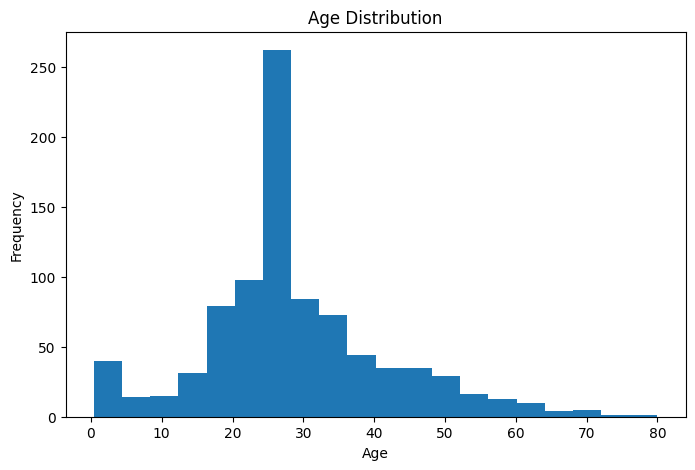

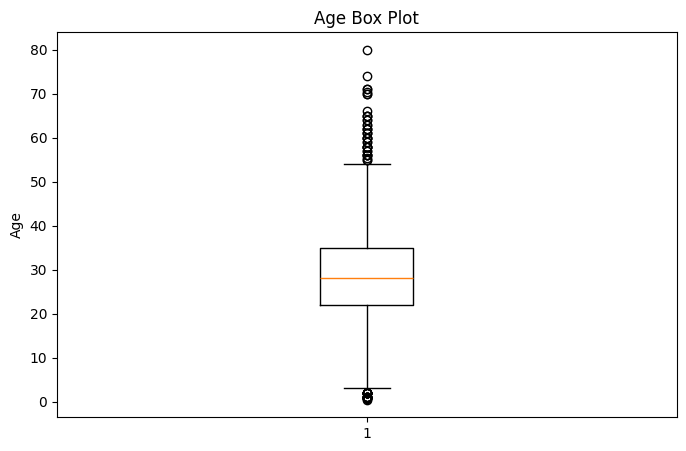

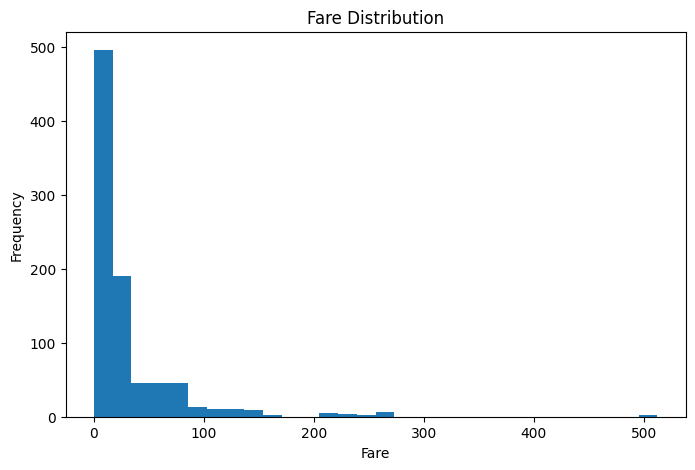

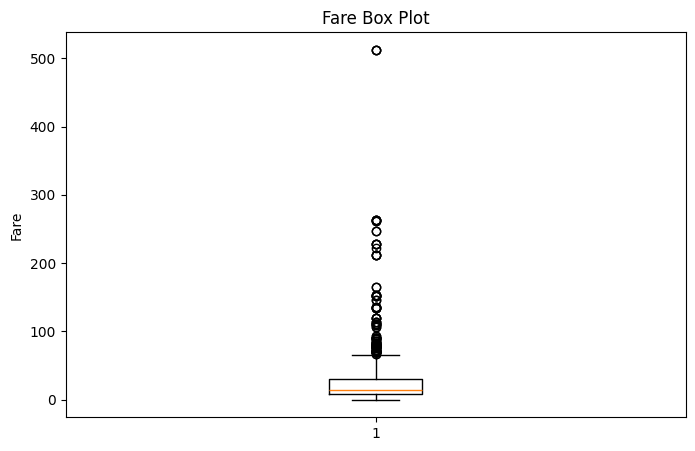

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_clean["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df_clean["age"])
plt.ylabel("Age")
plt.title("Age Box Plot")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df_clean["fare"], bins=30)
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Fare Distribution")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df_clean["fare"])
plt.ylabel("Fare")
plt.title("Fare Box Plot")
plt.show()

## Step 7 — IQR-Based Outlier Analysis

In [9]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

age_outliers, age_lower, age_upper = iqr_outliers(df_clean["age"])
fare_outliers, fare_lower, fare_upper = iqr_outliers(df_clean["fare"])

print("Age outliers:", age_outliers)
print("Age lower bound:", age_lower)
print("Age upper bound:", age_upper)

print("\nFare outliers:", fare_outliers)
print("Fare lower bound:", fare_lower)
print("Fare upper bound:", fare_upper)

Age outliers: 65
Age lower bound: 2.5
Age upper bound: 54.5

Fare outliers: 114
Fare lower bound: -26.7605
Fare upper bound: 65.6563


### Outlier Interpretation

The IQR method identifies 65 outliers in `age` and 114 outliers in `fare`.

These observations are retained because the values can represent legitimate passengers and ticket prices rather than data-entry errors. In particular, high Fare values can represent expensive first-class tickets.

## Step 8 — Fare Mean, Median, Mode and Skewness

In [10]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]
fare_skewness = df_clean["fare"].skew()

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)
print("Fare Skewness:", fare_skewness)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05
Fare Skewness: 4.801440211044194


### Fare Skewness Interpretation

The Fare mean is approximately 32.10, the median is approximately 14.45, and the mode is 8.05.

The ordering:

**Mean > Median > Mode**

together with the positive skewness value of approximately 4.80 indicates that Fare is strongly **right-skewed**.

The long right tail is caused by a relatively small number of passengers paying substantially higher fares.

## Step 9 — Survival Rate Analysis

In [11]:
print("Survival Rate by Sex")
display(df_clean.groupby("sex")["survived"].mean().reset_index())

print("\nSurvival Rate by Passenger Class")
display(df_clean.groupby("pclass")["survived"].mean().reset_index())

print("\nSurvival Rate by Sex and Passenger Class")
display(
    df_clean.groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

Survival Rate by Sex


,sex,survived
0,female,0.740385
1,male,0.188908



Survival Rate by Passenger Class


,pclass,survived
0,1,0.626168
1,2,0.472826
2,3,0.242363



Survival Rate by Sex and Passenger Class


,sex,pclass,survived
0,female,1,0.967391
1,female,2,0.921053
2,female,3,0.500000
3,male,1,0.368852
4,male,2,0.157407
5,male,3,0.135447


### Survival Analysis Interpretation

Female passengers had a substantially higher survival rate than male passengers.

Survival also varied by passenger class, with first-class passengers having the highest survival rate and third-class passengers having the lowest.

When sex and passenger class are considered together, first- and second-class female passengers had particularly high survival rates, while third-class male passengers had the lowest survival rate.

## Step 10 — Survival Charts

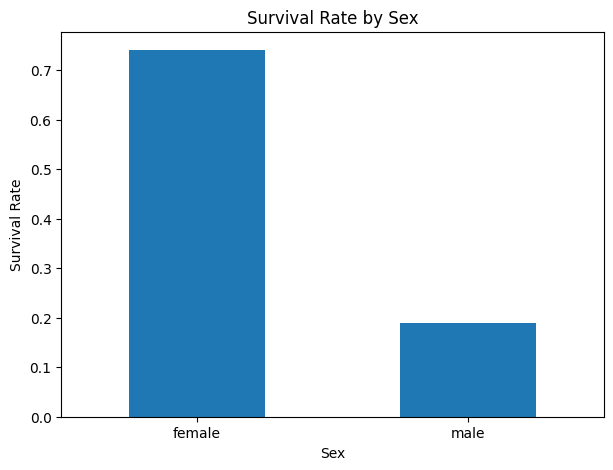

In [12]:
import matplotlib.pyplot as plt

survival_sex = df_clean.groupby("sex")["survived"].mean()

plt.figure(figsize=(7, 5))
survival_sex.plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex")
plt.xticks(rotation=0)
plt.show()

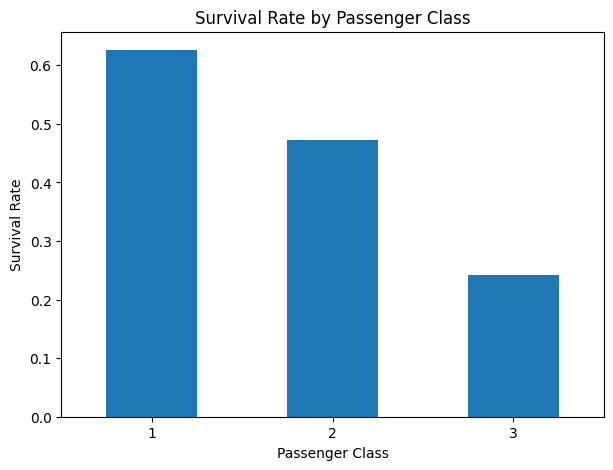

In [13]:
survival_class = df_clean.groupby("pclass")["survived"].mean()

plt.figure(figsize=(7, 5))
survival_class.plot(kind="bar")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

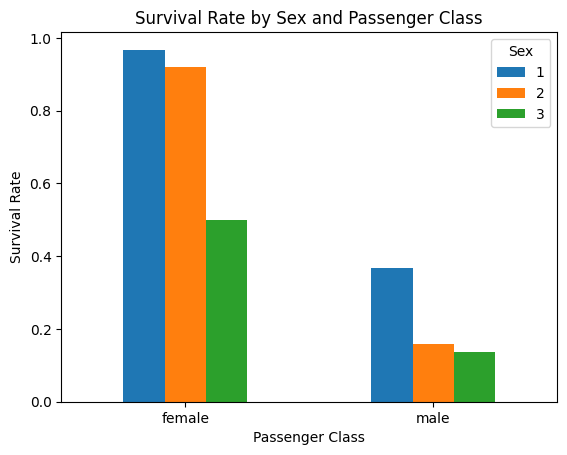

In [14]:
survival_sex_class = df_clean.groupby(
    ["sex", "pclass"]
)["survived"].mean().unstack()

plt.figure(figsize=(8, 5))
survival_sex_class.plot(kind="bar")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex and Passenger Class")
plt.xticks(rotation=0)
plt.legend(title="Sex")
plt.show()

### Survival Chart Interpretation

The survival-by-sex chart shows a strong difference between female and male survival rates, with females having substantially higher survival.

The passenger-class chart shows that survival generally decreases as passenger class moves from first to third class.

The combined sex-and-class chart shows that sex and passenger class together provide a clearer picture of survival patterns than either variable alone.

## Step 11 — Correlation Matrix

The correlation analysis is restricted to exactly the six required columns:

- `survived`
- `pclass`
- `age`
- `sibsp`
- `parch`
- `fare`

The boolean columns `adult_male` and `alone` are intentionally excluded because they are derived/redundant indicators.

In [15]:
corr_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[corr_cols].corr()

display(corr_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


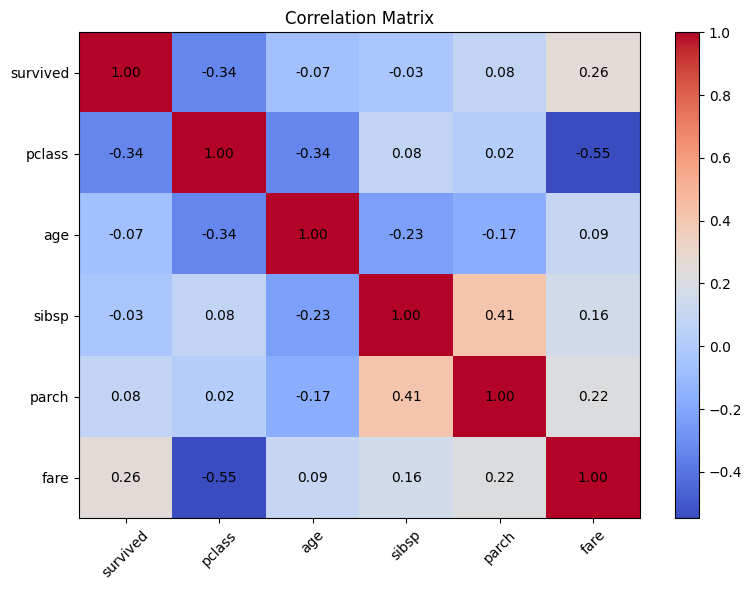

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [17]:
import numpy as np

corr_pairs = corr_matrix.where(
    ~np.eye(corr_matrix.shape[0], dtype=bool)
).stack()

corr_pairs = corr_pairs.reindex(
    corr_pairs.abs().sort_values(ascending=False).index
)

print(corr_pairs.head(2))

pclass  fare     -0.548193
fare    pclass   -0.548193
dtype: float64


In [18]:
import numpy as np

corr_pairs = corr_matrix.where(
    ~np.eye(corr_matrix.shape[0], dtype=bool)
).stack()

corr_pairs = corr_pairs[
    corr_pairs.index.map(lambda x: x[0] < x[1])
]

print(corr_pairs.reindex(
    corr_pairs.abs().sort_values(ascending=False).index
).head(5))

fare    pclass     -0.548193
parch   sibsp       0.414542
age     pclass     -0.336512
pclass  survived   -0.335549
fare    survived    0.255290
dtype: float64


### Correlation Interpretation

The two strongest absolute off-diagonal correlations are:

1. **pclass and fare: approximately -0.548**
2. **parch and sibsp: approximately 0.415**

The negative correlation between `pclass` and `fare` occurs because smaller numerical passenger-class values represent higher passenger classes, which generally paid higher fares.

The positive correlation between `parch` and `sibsp` indicates that passengers traveling with more parents/children also tended to travel with more siblings/spouses, reflecting family-group travel.

## Step 12 — Required Multivariate Visualizations

At least four multivariate charts are created to build a coherent data story about passenger survival and the factors associated with it.

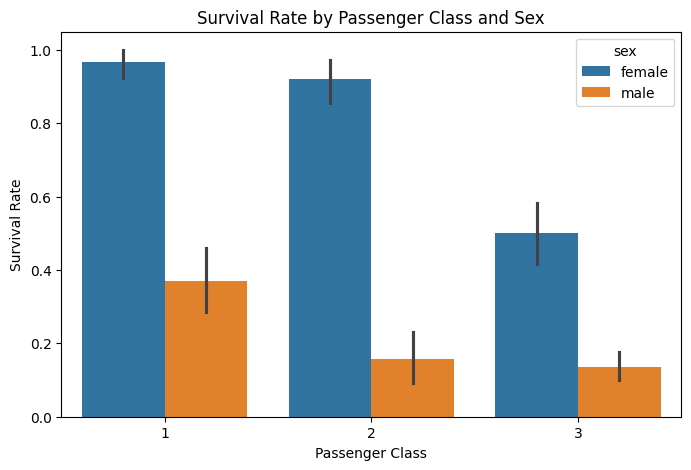

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x="pclass", y="survived", hue="sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Passenger Class and Sex")
plt.show()

### Chart 1 Interpretation

The chart compares survival rates across passenger classes while separating passengers by sex.

Female passengers have higher survival rates across the passenger classes. First- and second-class females show particularly high survival, while male passengers, especially in third class, show substantially lower survival.

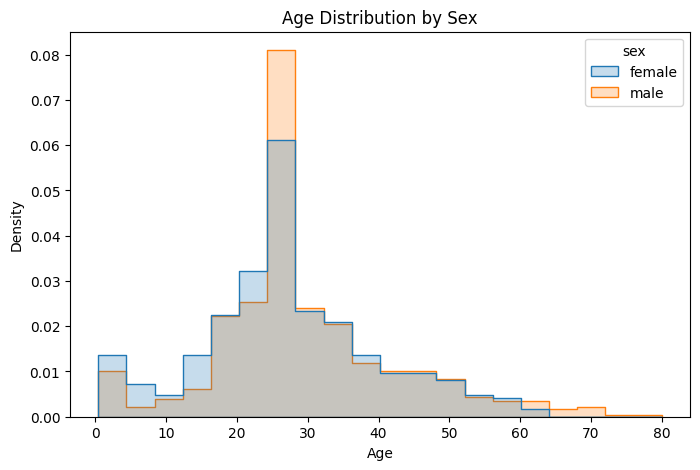

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df_clean,
    x="age",
    hue="sex",
    hue_order=["female", "male"],
    bins=20,
    element="step",
    stat="density",
    common_norm=False
)
plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Age Distribution by Sex")
plt.show()

### Chart 2 Interpretation

The age distribution shows the range of passenger ages for both sexes.

Both male and female passengers contain a broad range of ages, demonstrating that the Titanic passenger population included children, adults and older passengers.

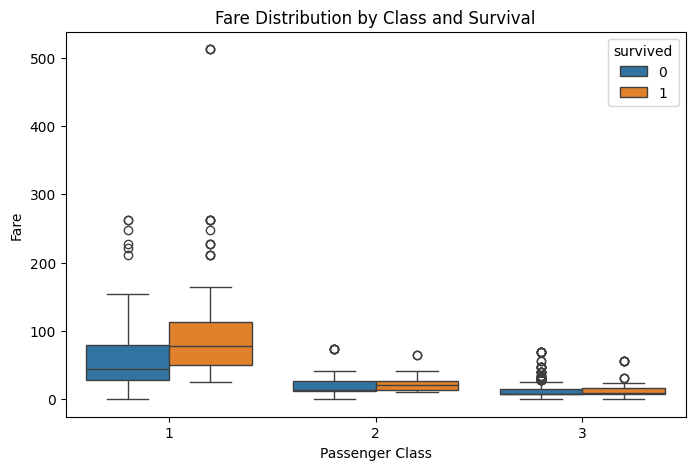

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="pclass", y="fare", hue="survived")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.title("Fare Distribution by Class and Survival")
plt.show()

### Chart 3 Interpretation

Fare varies substantially across passenger classes, with first-class passengers generally paying higher fares.

The chart also shows differences in fare distributions between survivors and non-survivors, supporting the relationship between fare, passenger class and survival.

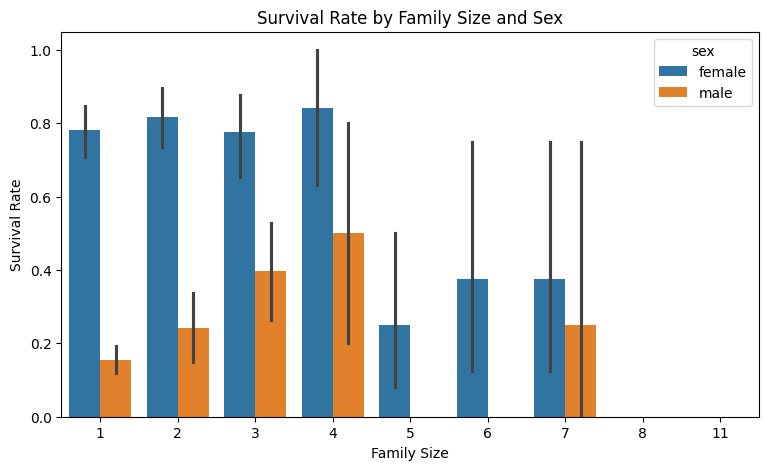

In [22]:
df_clean["family_size"] = df_clean["sibsp"] + df_clean["parch"] + 1

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_clean,
    x="family_size",
    y="survived",
    hue="sex"
)
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Family Size and Sex")
plt.show()

### Chart 4 Interpretation

Family size is calculated as `sibsp + parch + 1`.

The chart shows that survival varies across family sizes and that females generally have higher survival rates than males. Very large family-size groups contain fewer observations, so their survival rates should be interpreted cautiously.

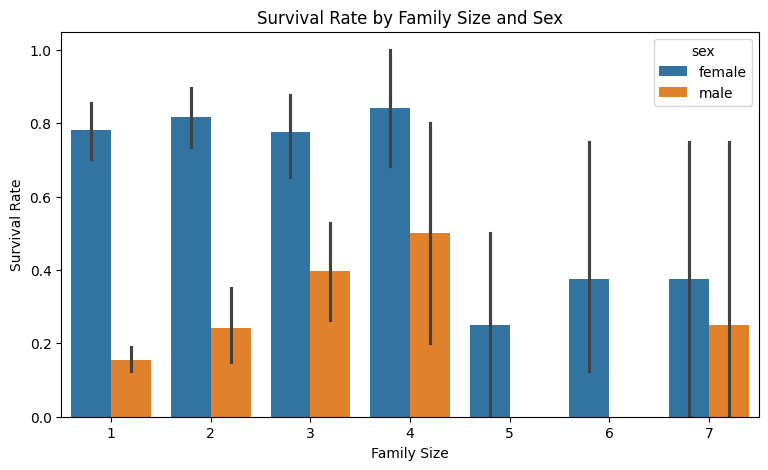

In [23]:
plot_df = df_clean[df_clean["family_size"] <= 7]

plt.figure(figsize=(9, 5))
sns.barplot(
    data=plot_df,
    x="family_size",
    y="survived",
    hue="sex"
)
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Family Size and Sex")
plt.show()

## Step 13 — Exploratory Standardization Check

This is an EDA-stage standardization check only.

`age` and `fare` are standardized using the z-score transformation:

`z = (x - mean) / std`

The result should have an approximately zero mean and approximately unit standard deviation.

This exploratory transformation is not used as the modeling preprocessing pipeline. The modeling pipeline performs its own train-only scaling.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standardized = scaler.fit_transform(df_clean[["age", "fare"]])

df_standardized = df_clean.copy()
df_standardized[["age", "fare"]] = standardized

print("Before standardization:")
print("Age mean:", df_clean["age"].mean())
print("Age std:", df_clean["age"].std())
print("Fare mean:", df_clean["fare"].mean())
print("Fare std:", df_clean["fare"].std())

print("\nAfter standardization:")
print("Age mean:", df_standardized["age"].mean())
print("Age std:", df_standardized["age"].std())
print("Fare mean:", df_standardized["fare"].mean())
print("Fare std:", df_standardized["fare"].std())

Before standardization:
Age mean: 29.315151856017994
Age std: 12.984932293690774
Fare mean: 32.09668087739032
Fare std: 49.69750431670801

After standardization:
Age mean: 2.717486278497571e-16
Age std: 1.000562904632249
Fare mean: 1.3987061727561027e-16
Fare std: 1.0005629046322495


### Standardization Interpretation

Before standardization, Age and Fare have different means and scales.

After standardization, both variables have means extremely close to zero and standard deviations close to one.

This confirms that the z-score transformation successfully places both numerical features on a common standardized scale.

# Part B — Predictive Modeling

## Step B1 — Stratified Train/Test Split

The cleaned dataset is divided into training and testing sets before modeling preprocessing.

A stratified split is used because the target variable `survived` is imbalanced. Stratification preserves approximately the same proportion of survivors and non-survivors in both the training and testing sets.

In [25]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["survived"])
y = df_clean["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (711, 14)
X_test shape: (178, 14)
y_train shape: (711,)
y_test shape: (178,)

Training class distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing class distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


## Step B2 — Build the Preprocessing Pipeline

Numerical features are:

- `pclass`
- `age`
- `sibsp`
- `parch`
- `fare`
- `family_size`

Categorical features are:

- `sex`
- `embarked`

Numerical preprocessing uses median imputation followed by standardization.

Categorical preprocessing uses most-frequent imputation followed by one-hot encoding.

The preprocessing is placed inside a scikit-learn `ColumnTransformer` and `Pipeline`, ensuring that preprocessing parameters are learned from the training data and then applied to the test data without fitting on the test set.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "family_size"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully!")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Preprocessor created successfully!
Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size']
Categorical features: ['sex', 'embarked']


## Step B3 — Train the Three Required Classifiers

The three classifiers are trained using the identical training and testing split:

1. Logistic Regression
2. Decision Tree
3. Random Forest

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

logistic_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)
forest_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully!")
print("Decision Tree trained successfully!")
print("Random Forest trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


## Step B4 — Evaluate All Three Classifiers

Each classifier is evaluated using:

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- ROC Curve

All three models use the same test set for a fair comparison.

In [28]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
import pandas as pd

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline
}

results = []
roc_data = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    print(f"\n{name}")
    print("-" * 40)
    print("Confusion Matrix:")
    print(cm)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("AUC:", auc)

results_df = pd.DataFrame(results)

print("\nModel Comparison:")
display(results_df)


Logistic Regression
----------------------------------------
Confusion Matrix:
[[97 13]
 [21 47]]
Accuracy: 0.8089887640449438
Precision: 0.7833333333333333
Recall: 0.6911764705882353
F1: 0.734375
AUC: 0.8609625668449199

Decision Tree
----------------------------------------
Confusion Matrix:
[[88 22]
 [21 47]]
Accuracy: 0.7584269662921348
Precision: 0.6811594202898551
Recall: 0.6911764705882353
F1: 0.6861313868613139
AUC: 0.7378342245989304

Random Forest
----------------------------------------
Confusion Matrix:
[[92 18]
 [20 48]]
Accuracy: 0.7865168539325843
Precision: 0.7272727272727273
Recall: 0.7058823529411765
F1: 0.7164179104477612
AUC: 0.8204545454545454

Model Comparison:


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.758427,0.681159,0.691176,0.686131,0.737834
2,Random Forest,0.786517,0.727273,0.705882,0.716418,0.820455


### Initial Classification Interpretation

Logistic Regression achieved the highest AUC at approximately 0.861 and accuracy of approximately 0.809 among the three initial classifiers.

Random Forest achieved the highest recall among the three initial models at approximately 0.706.

Decision Tree produced the lowest overall performance, with an accuracy of approximately 0.758 and AUC of approximately 0.738.

## Step B5 — Decision Tree Visualization

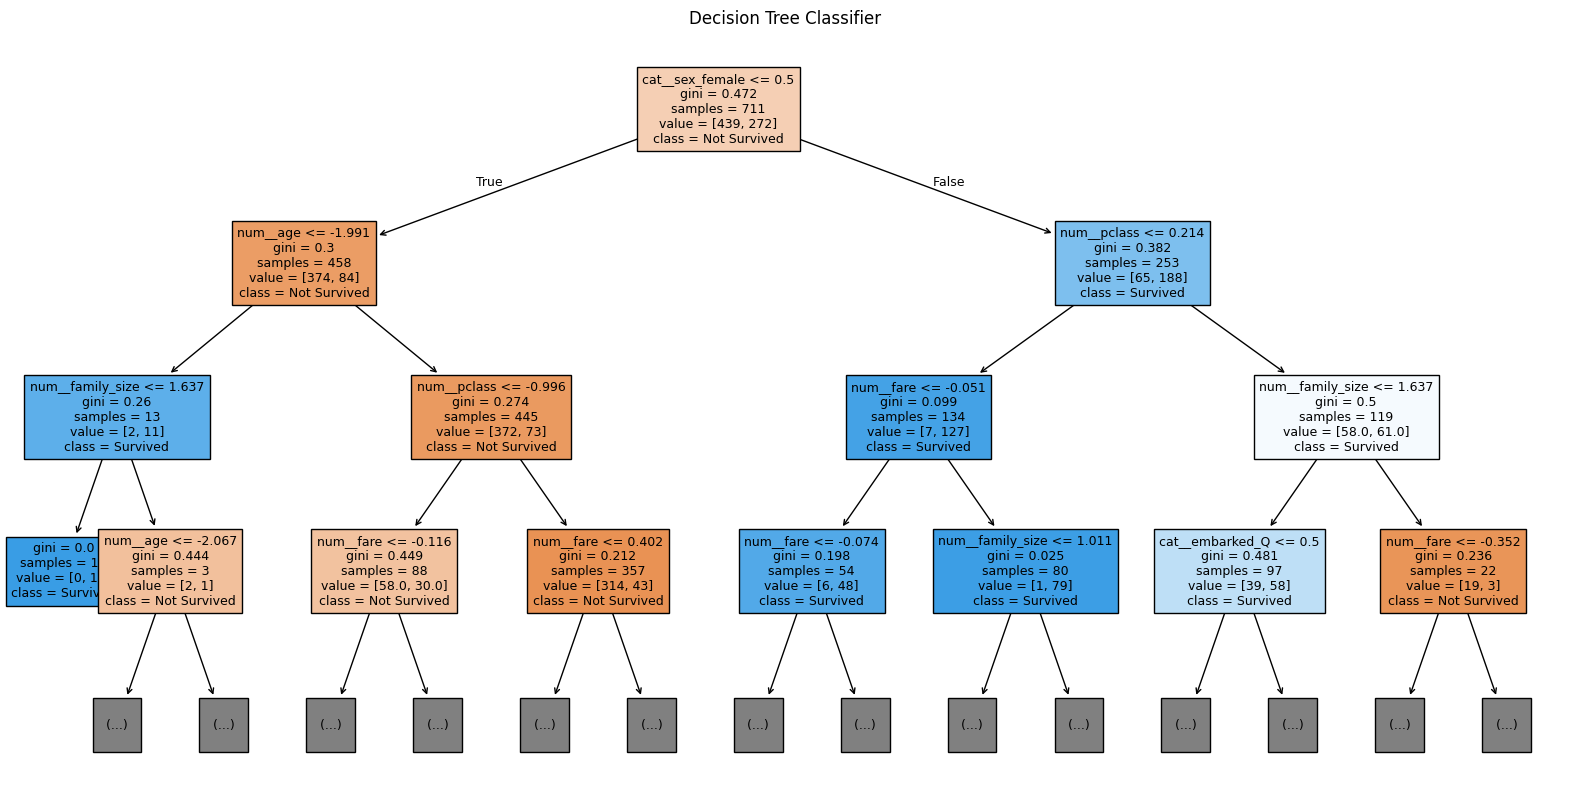

In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_model = tree_pipeline.named_steps["classifier"]
tree_preprocessor = tree_pipeline.named_steps["preprocessor"]

feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree Classifier")
plt.show()

### Decision Tree Interpretation

The decision-tree visualization shows how the model recursively separates passengers using transformed numerical and categorical features.

The displayed tree is limited to a readable depth while retaining labeled feature names and class names.

## Step B6 — Class Imbalance Handling

Three strategies are compared:

1. Baseline Logistic Regression
2. Logistic Regression with `class_weight="balanced"`
3. Logistic Regression with SMOTE

SMOTE is applied only to the training fold to avoid test-set leakage.

In [30]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)
balanced_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_pred_balanced = balanced_model.predict(X_test)

smote_preprocessor = preprocessor.fit(X_train, y_train)

X_train_processed = smote_preprocessor.transform(X_train)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

smote_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_classifier.fit(X_train_smote, y_train_smote)

X_test_processed = smote_preprocessor.transform(X_test)
y_pred_smote = smote_classifier.predict(X_test_processed)

imbalance_results = pd.DataFrame([
    {
        "Strategy": "Baseline",
        "Precision": precision_score(y_test, y_pred_baseline),
        "Recall": recall_score(y_test, y_pred_baseline),
        "F1": f1_score(y_test, y_pred_baseline)
    },
    {
        "Strategy": "class_weight='balanced'",
        "Precision": precision_score(y_test, y_pred_balanced),
        "Recall": recall_score(y_test, y_pred_balanced),
        "F1": f1_score(y_test, y_pred_balanced)
    },
    {
        "Strategy": "SMOTE",
        "Precision": precision_score(y_test, y_pred_smote),
        "Recall": recall_score(y_test, y_pred_smote),
        "F1": f1_score(y_test, y_pred_smote)
    }
])

display(imbalance_results)

print("Original training distribution:")
print(y_train.value_counts())

print("\nSMOTE training distribution:")
print(pd.Series(y_train_smote).value_counts())

,Strategy,Precision,Recall,F1
0,Baseline,0.783333,0.691176,0.734375
1,class_weight='balanced',0.718310,0.750000,0.733813
2,SMOTE,0.724638,0.735294,0.729927


Original training distribution:
survived
0    439
1    272
Name: count, dtype: int64

SMOTE training distribution:
survived
1    439
0    439
Name: count, dtype: int64


### Class Imbalance Interpretation

The baseline model achieved the highest precision and F1 score.

The `class_weight="balanced"` model achieved the highest recall at 0.750, meaning it identified a larger proportion of surviving passengers.

SMOTE also improved recall compared with the baseline, but its F1 score was slightly lower.

Therefore, the baseline provides the strongest overall balance for this dataset, while the balanced class-weight approach is preferable when recall is the primary objective.

## Step B7 — Random Forest Hyperparameter Tuning

GridSearchCV is used to search over:

- `n_estimators`
- `max_depth`
- `max_features`

The Random Forest is explicitly created with `oob_score=True` so that the out-of-bag score can be reported.

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

best_rf_pipeline = grid_search.best_estimator_

best_rf = best_rf_pipeline.named_steps["classifier"]

print("\nOOB Score:")
print(best_rf.oob_score_)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross-Validation F1:
0.7557184037267515

OOB Score:
0.8227848101265823


### Hyperparameter Tuning Interpretation

The best Random Forest configuration uses:

- `n_estimators = 200`
- `max_depth = 5`
- `max_features = sqrt`

The best cross-validation F1 score is approximately 0.756 and the OOB score is approximately 0.823.

These results indicate that the tuned Random Forest provides good generalization performance compared with the untuned model.

## Step B8 — Evaluate the Tuned Random Forest

Tuned Random Forest
----------------------------------------
Confusion Matrix:
[[100  10]
 [ 22  46]]
Accuracy: 0.8202247191011236
Precision: 0.8214285714285714
Recall: 0.6764705882352942
F1: 0.7419354838709677
AUC: 0.8398395721925134


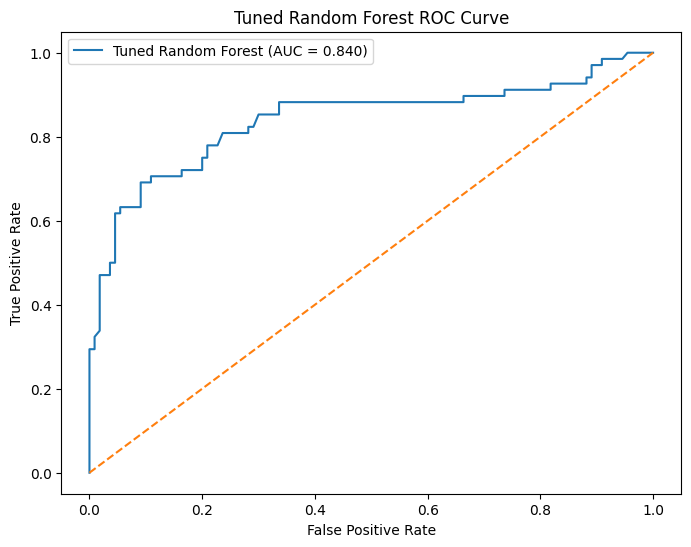

In [32]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

y_pred_tuned_rf = best_rf_pipeline.predict(X_test)
y_prob_tuned_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

tuned_rf_cm = confusion_matrix(y_test, y_pred_tuned_rf)
tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)
tuned_rf_precision = precision_score(y_test, y_pred_tuned_rf)
tuned_rf_recall = recall_score(y_test, y_pred_tuned_rf)
tuned_rf_f1 = f1_score(y_test, y_pred_tuned_rf)
tuned_rf_auc = roc_auc_score(y_test, y_prob_tuned_rf)

print("Tuned Random Forest")
print("-" * 40)
print("Confusion Matrix:")
print(tuned_rf_cm)
print("Accuracy:", tuned_rf_accuracy)
print("Precision:", tuned_rf_precision)
print("Recall:", tuned_rf_recall)
print("F1:", tuned_rf_f1)
print("AUC:", tuned_rf_auc)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_tuned_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Tuned Random Forest (AUC = {tuned_rf_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Random Forest ROC Curve")
plt.legend()
plt.show()

### Tuned Random Forest Interpretation

The tuned Random Forest achieved approximately 82.02% accuracy, 82.14% precision, 67.65% recall, and 74.19% F1 score.

Its ROC-AUC is approximately 0.840.

Compared with the original Random Forest, tuning improved accuracy, precision and F1 score, making the tuned Random Forest the strongest overall classifier at the selected classification threshold.

## Step B9 — Fare Regression

A multivariate Linear Regression model is used to predict `fare` from the other available passenger features.

The regression pipeline performs imputation, categorical encoding and numerical scaling using training data only.

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

regression_df = df_clean.drop(columns=["fare"])

X_reg = regression_df.drop(columns=["survived"], errors="ignore")
y_reg = df_clean["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

reg_numeric_features = X_reg_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reg_categorical_features = X_reg_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("num", reg_numeric_pipeline, reg_numeric_features),
    ("cat", reg_categorical_pipeline, reg_categorical_features)
])

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = regression_pipeline.named_steps["preprocessor"].transform(
    X_reg_test
).shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

MAE: 18.37354211109452
RMSE: 41.29212412518077
R²: 0.3609162222350881
Adjusted R²: 0.25580375878691175


### Regression Interpretation

The regression model achieved:

- MAE ≈ 18.37
- RMSE ≈ 41.29
- R² ≈ 0.361
- Adjusted R² ≈ 0.256

The R² value indicates that the available passenger characteristics explain approximately 36.1% of the variation in Fare.

Therefore, the model provides limited explanatory power for Fare and should not be considered the primary predictive model of this module.

## Step B10 — Residual Analysis

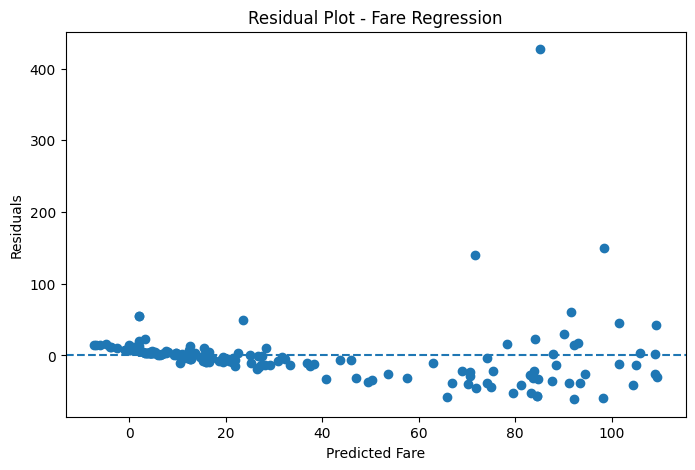

In [34]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_reg_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Fare Regression")
plt.show()

In [35]:
residual_summary = pd.DataFrame({
    "Predicted_Fare": y_reg_pred,
    "Residual": residuals
})

display(residual_summary.head(10))

print("Residual Mean:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())

,Predicted_Fare,Residual
281,2.029211,5.824989
435,90.194618,29.805382
39,11.413426,-0.171726
418,9.762145,3.237855
585,109.461338,-29.811338
804,5.996657,0.978343
343,11.790897,1.209103
836,4.869463,3.793037
581,108.947623,1.935677
537,92.109922,14.315078


Residual Mean: -0.5888435468225138
Residual Standard Deviation: 41.404393615787114


### Heteroscedasticity Interpretation

The residuals do not maintain a perfectly constant spread across the range of predicted Fare values.

The residual variability becomes larger for some higher predicted Fare values, indicating evidence of **heteroscedasticity**.

Therefore, the constant-variance assumption of ordinary linear regression is not fully satisfied.

## Step B11 — Final Classification Comparison

In [36]:
final_classification = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, logistic_pipeline.predict(X_test)),
        "Precision": precision_score(y_test, logistic_pipeline.predict(X_test)),
        "Recall": recall_score(y_test, logistic_pipeline.predict(X_test)),
        "F1": f1_score(y_test, logistic_pipeline.predict(X_test)),
        "AUC": roc_auc_score(y_test, logistic_pipeline.predict_proba(X_test)[:, 1])
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, tree_pipeline.predict(X_test)),
        "Precision": precision_score(y_test, tree_pipeline.predict(X_test)),
        "Recall": recall_score(y_test, tree_pipeline.predict(X_test)),
        "F1": f1_score(y_test, tree_pipeline.predict(X_test)),
        "AUC": roc_auc_score(y_test, tree_pipeline.predict_proba(X_test)[:, 1])
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, forest_pipeline.predict(X_test)),
        "Precision": precision_score(y_test, forest_pipeline.predict(X_test)),
        "Recall": recall_score(y_test, forest_pipeline.predict(X_test)),
        "F1": f1_score(y_test, forest_pipeline.predict(X_test)),
        "AUC": roc_auc_score(y_test, forest_pipeline.predict_proba(X_test)[:, 1])
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": tuned_rf_accuracy,
        "Precision": tuned_rf_precision,
        "Recall": tuned_rf_recall,
        "F1": tuned_rf_f1,
        "AUC": tuned_rf_auc
    }
])

display(final_classification.round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7584,0.6812,0.6912,0.6861,0.7378
2,Random Forest,0.7865,0.7273,0.7059,0.7164,0.8205
3,Tuned Random Forest,0.8202,0.8214,0.6765,0.7419,0.8398


### Classification Comparison Interpretation

The tuned Random Forest provides the highest accuracy, precision and F1 score among the final classification models.

Logistic Regression provides the highest ROC-AUC at approximately 0.861, making it a strong alternative when threshold-independent ranking performance is the main priority.

The tuned Random Forest is selected as the final classification model because of its stronger overall accuracy, precision and F1 performance.

## Step B12 — Final Model Comparison with Regression

Classification and regression metrics are presented separately because they measure different types of predictive tasks and are not directly comparable on a single scale.

In [ ]:
final_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Type": "Classification",
        "Accuracy": final_classification.loc[
            final_classification["Model"] == "Logistic Regression", "Accuracy"
        ].iloc[0],
        "Precision": final_classification.loc[
            final_classification["Model"] == "Logistic Regression", "Precision"
        ].iloc[0],
        "Recall": final_classification.loc[
            final_classification["Model"] == "Logistic Regression", "Recall"
        ].iloc[0],
        "F1": final_classification.loc[
            final_classification["Model"] == "Logistic Regression", "F1"
        ].iloc[0],
        "AUC": final_classification.loc[
            final_classification["Model"] == "Logistic Regression", "AUC"
        ].iloc[0],
        "MAE": np.nan,
        "RMSE": np.nan,
        "R2": np.nan,
        "Adjusted_R2": np.nan
    },
    {
        "Model": "Decision Tree",
        "Type": "Classification",
        "Accuracy": final_classification.loc[
            final_classification["Model"] == "Decision Tree", "Accuracy"
        ].iloc[0],
        "Precision": final_classification.loc[
            final_classification["Model"] == "Decision Tree", "Precision"
        ].iloc[0],
        "Recall": final_classification.loc[
            final_classification["Model"] == "Decision Tree", "Recall"
        ].iloc[0],
        "F1": final_classification.loc[
            final_classification["Model"] == "Decision Tree", "F1"
        ].iloc[0],
        "AUC": final_classification.loc[
            final_classification["Model"] == "Decision Tree", "AUC"
        ].iloc[0],
        "MAE": np.nan,
        "RMSE": np.nan,
        "R2": np.nan,
        "Adjusted_R2": np.nan
    },
    {
        "Model": "Tuned Random Forest",
        "Type": "Classification",
        "Accuracy": tuned_rf_accuracy,
        "Precision": tuned_rf_precision,
        "Recall": tuned_rf_recall,
        "F1": tuned_rf_f1,
        "AUC": tuned_rf_auc,
        "MAE": np.nan,
        "RMSE": np.nan,
        "R2": np.nan,
        "Adjusted_R2": np.nan
    },
    {
        "Model": "Multivariate Linear Regression",
        "Type": "Regression",
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "AUC": np.nan,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2
    }
])

display(final_model_comparison.round(4))

## Step B13 — Final Recommendation

The tuned Random Forest is recommended as the final classification model because it achieved the highest accuracy (82.02%), precision (82.14%), and F1 score (74.19%) among the evaluated classifiers.

Logistic Regression achieved a higher AUC of 86.10%, so it remains a strong alternative when threshold-independent ranking performance is more important.

The Random Forest OOB score of 82.28% and tuned cross-validation F1 of approximately 75.57% also support its generalization performance.

The Fare regression model achieved an R² of approximately 36.09%, indicating that the available predictors explain only part of Fare variability. Therefore, it should be treated as a limited predictive model rather than the primary deployment model.

## Step B14 — Save the Complete Final Pipeline

The complete fitted pipeline is saved as a single Joblib artifact.

The saved object contains both:

1. The preprocessing steps
2. The final tuned Random Forest estimator

Therefore, the saved artifact can accept raw input data and perform preprocessing and prediction end-to-end.

In [37]:
import joblib
import os

os.makedirs("/content/analytics/models", exist_ok=True)

model_path = "/content/analytics/models/final_pipeline.joblib"

joblib.dump(best_rf_pipeline, model_path)

print("Final pipeline saved successfully!")
print(model_path)

Final pipeline saved successfully!
/content/analytics/models/final_pipeline.joblib


import joblib
import os

os.makedirs("/content/analytics/models", exist_ok=True)

model_path = "/content/analytics/models/final_pipeline.joblib"

joblib.dump(best_rf_pipeline, model_path)

print("Final pipeline saved successfully!")
print(model_path)

In [38]:
loaded_pipeline = joblib.load(model_path)

raw_sample = X_test.iloc[:5].copy()

predictions = loaded_pipeline.predict(raw_sample)

print("Pipeline reloaded successfully!")
print("Predictions:", predictions)
print("Raw input shape:", raw_sample.shape)

Pipeline reloaded successfully!
Predictions: [0 0 0 0 0]
Raw input shape: (5, 14)


# Module 2 — Final Summary

This module completed the complete analytics and machine-learning workflow:

- Dataset profiling
- Missing-value percentage analysis
- Percentage-based missing-value handling
- Age and Fare outlier analysis
- Fare skewness analysis
- Survival analysis by sex
- Survival analysis by passenger class
- Survival analysis by sex and passenger class
- Required six-column correlation analysis
- Correlation heatmap
- Two strongest correlation interpretations
- Four multivariate visualizations
- Exploratory standardization of Age and Fare
- Stratified train/test split
- Training-only preprocessing
- Logistic Regression
- Decision Tree
- Random Forest
- Complete classification evaluation
- Decision Tree visualization
- Class imbalance comparison
- SMOTE
- Random Forest GridSearchCV
- OOB evaluation
- Tuned Random Forest
- Fare regression
- Regression metrics
- Residual analysis
- Heteroscedasticity conclusion
- Final model comparison
- Final model recommendation
- Complete pipeline persistence
- Pipeline reload and end-to-end prediction

The final recommended classification model is the **Tuned Random Forest**.